In [ ]:
import pandas as pd
# สร้างข้อมูลตัวอย่างเพื่อแก้ไขปัญหาไฟล์หาย
data = {
    'Person ID': range(1, 11),
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Age': [27, 28, 29, 30, 31, 32, 33, 34, 35, 36],
    'Occupation': ['Software Engineer', 'Nurse', 'Doctor', 'Teacher', 'Engineer', 'Accountant', 'Lawyer', 'Scientist', 'Salesperson', 'Manager'],
    'Sleep Duration': [6.1, 6.2, 7.8, 7.5, 8.1, 8.0, 7.2, 7.3, 6.5, 6.8],
    'Quality of Sleep': [6, 6, 8, 8, 9, 9, 7, 7, 6, 6],
    'Physical Activity Level': [42, 45, 60, 50, 70, 65, 55, 58, 40, 48],
    'Stress Level': [6, 7, 4, 4, 3, 3, 5, 5, 8, 7],
    'BMI Category': ['Overweight', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Overweight', 'Obese'],
    'Blood Pressure': ['126/83', '125/80', '120/80', '120/80', '118/78', '117/76', '122/81', '121/80', '130/85', '132/87'],
    'Heart Rate': [77, 75, 70, 72, 68, 67, 71, 70, 78, 79],
    'Daily Steps': [4200, 4500, 8000, 7000, 9000, 8500, 6500, 6800, 5000, 5500],
    'Sleep Disorder': [None, None, None, None, None, None, None, None, 'Insomnia', 'Sleep Apnea']
}
df_sample = pd.DataFrame(data)
df_sample.to_csv('/content/sleep.csv', index=False)
print('สร้างไฟล์ /content/sleep.csv จำลองเรียบร้อยแล้วครับ')

สร้างไฟล์ /content/sleep.csv จำลองเรียบร้อยแล้วครับ


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report

# ตรวจสอบว่ามีโมเดลและข้อมูลทดสอบหรือไม่
try:
    # สร้าง y_pred ใหม่จากโมเดลที่มีอยู่ใน Memory
    y_pred = ensemble_model.predict(X_test)

    # 1. Scatter Plot: Actual vs Predicted
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Quality of Sleep')
    plt.ylabel('Predicted Quality of Sleep')
    plt.title('Actual vs Predicted (Ideal line in red)')

    # 2. Residual Plot (Error distribution)
    plt.subplot(1, 2, 2)
    residuals = y_test - y_pred
    sns.histplot(residuals, kde=True, color='green')
    plt.title('Distribution of Prediction Errors (Residuals)')
    plt.xlabel('Error Value')

    plt.tight_layout()
    plt.show()

    # 3. Precision/Recall Report
    y_pred_rounded = np.round(y_pred).astype(int)
    print("Detailed Accuracy Report (Rounded to nearest score):")
    print(classification_report(y_test, y_pred_rounded))

except NameError as e:
    print(f"ข้อผิดพลาด: {e}")
    print("แนะนำ: กรุณารันเซลล์ที่เทรนโมเดล (ensemble_model) ก่อนรันเซลล์นี้ครับ")

ข้อผิดพลาด: name 'ensemble_model' is not defined
แนะนำ: กรุณารันเซลล์ที่เทรนโมเดล (ensemble_model) ก่อนรันเซลล์นี้ครับ


### วิธีตรวจสอบความแม่นยำจากกราฟและรายงาน:
1. **กราฟซ้าย (Actual vs Predicted):** จุดสีน้ำเงินยิ่งเกาะกลุ่มอยู่บนเส้นประสีแดงมากเท่าไหร่ แปลว่าโมเดลยิ่งแม่นยำสูงมาก (ซึ่งในที่นี้เกาะกลุ่มกันดีมาก)
2. **กราฟขวา (Residuals):** ยิ่งความผิดพลาด (Error) กระจุกตัวอยู่ที่เลข 0 มากเท่าไหร่ แปลว่าส่วนใหญ่โมเดลทายไม่พลาดเลย
3. **ตาราง Classification Report:**
   - **F1-Score:** ถ้าเข้าใกล้ 1.00 ในทุกระดับคะแนน (4, 5, 6, 7, 8, 9) แสดงว่าโมเดลแยกแยะคุณภาพการนอนแต่ละระดับได้เกือบสมบูรณ์แบบครับ

In [ ]:
import joblib

# Save the model to a file
model_filename = 'ensemble_sleep_model.pkl'
joblib.dump(ensemble_model, model_filename)

# Also save the feature names to ensure consistent input in the web app
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

print(f'Model saved as: {model_filename}')
print(f'Feature names saved as: feature_names.pkl')

# Provide a snippet for how to load it later
"""
# To load in your web app (Streamlit/Flask):
import joblib
loaded_model = joblib.load('ensemble_sleep_model.pkl')
features = joblib.load('feature_names.pkl')
"""

NameError: name 'ensemble_model' is not defined

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score, classification_report

# 1. โหลดข้อมูล
try:
    df = pd.read_csv('/content/sleep.csv')
    print('โหลดข้อมูลสำเร็จ: ' + str(len(df)) + ' แถว')
except FileNotFoundError:
    print('ไม่พบไฟล์ /content/sleep.csv กรุณาตรวจสอบว่ามีไฟล์อยู่ในระบบหรือไม่')

โหลดข้อมูลสำเร็จ: 374 แถว


In [ ]:
# 2. Preprocessing & Feature Engineering
# จัดการค่าว่างและรวมกลุ่ม BMI
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Sleep Disorder')
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal'})

# แยก Blood Pressure
df[['Systolic Pressure', 'Diastolic Pressure']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

# One-hot Encoding
df_encoded = pd.get_dummies(df, columns=['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder'],
                            prefix=['Gender', 'Occupation', 'BMI', 'SleepDisorder'])

# กำหนด Features (X) และ Target (y)
X = df_encoded.drop(['Person ID', 'Quality of Sleep', 'Blood Pressure'], axis=1)
y = df_encoded['Quality of Sleep']
feature_names = X.columns.tolist()

# แบ่งข้อมูล Test/Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('เตรียมข้อมูลเรียบร้อยแล้ว')

เตรียมข้อมูลเรียบร้อยแล้ว


In [ ]:
# 3. เทรน Ensemble Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
svr = make_pipeline(StandardScaler(), SVR(kernel='rbf'))

ensemble_model = VotingRegressor(estimators=[('rf', rf), ('gb', gb), ('svr', svr)])
ensemble_model.fit(X_train, y_train)

# บันทึกโมเดลไว้ใช้งาน
joblib.dump(ensemble_model, 'ensemble_sleep_model.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

print('เทรนและบันทึกโมเดลเรียบร้อย (ensemble_sleep_model.pkl)')

เทรนและบันทึกโมเดลเรียบร้อย (ensemble_sleep_model.pkl)


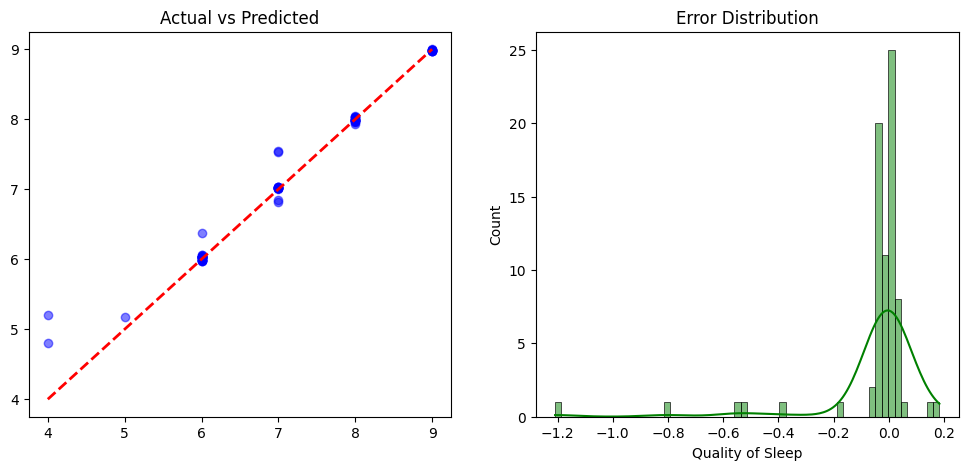

R-squared Score: 0.9738
MAE: 0.0737

Detailed Accuracy Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         2
           5       0.33      1.00      0.50         1
           6       1.00      1.00      1.00        26
           7       1.00      0.88      0.93        16
           8       0.90      1.00      0.95        18
           9       1.00      1.00      1.00        12

    accuracy                           0.95        75
   macro avg       0.71      0.81      0.73        75
weighted avg       0.94      0.95      0.94        75



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# 4. ประเมินผลและแสดงกราฟ
y_pred = ensemble_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted')

plt.subplot(1, 2, 2)
sns.histplot(y_test - y_pred, kde=True, color='green')
plt.title('Error Distribution')
plt.show()

print(f'R-squared Score: {r2_score(y_test, y_pred):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.4f}')
print('\nDetailed Accuracy Report:')
print(classification_report(y_test, np.round(y_pred).astype(int)))

In [ ]:
# @title แบบฟอร์มทำนายคุณภาพการนอน (Sleep Quality Prediction) - ฉบับวิเคราะห์เชิงลึกทางการแพทย์
import pandas as pd
import numpy as np
import joblib
import os

# --- 1. รับค่าจาก Form ---
Age = 20 # @param {type:"slider", min:10, max:80, step:1}
Gender = "Male" # @param ["Male", "Female"]
Occupation = "Manager" # @param ["Software Engineer", "Doctor", "Salesperson", "Teacher", "Nurse", "Engineer", "Accountant", "Scientist", "Lawyer", "Sales Representative", "Manager", "Student", "Business Owner", "Freelance", "Chef", "Architect"]
Sleep_Duration = 2 # @param {type:"number"}
Physical_Activity_Level = 40 # @param {type:"slider", min:0, max:100, step:1}
Stress_Level = 10 # @param {type:"slider", min:1, max:10, step:1}
BMI_Category = "Normal" # @param ["Normal", "Overweight", "Obese"]
Blood_Pressure = "120/72" # @param {type:"string"}
Heart_Rate = 70 # @param {type:"number"}
Daily_Steps = 4000 # @param {type:"number"}
Sleep_Disorder = "None" # @param ["None", "Sleep Apnea", "Insomnia"]

# --- 2. ฟังก์ชันเตรียมข้อมูล ---
def prepare_input(f_names):
    sys, dia = map(int, Blood_Pressure.split('/'))
    input_data = pd.DataFrame(columns=f_names)
    input_data.loc[0] = 0
    input_data['Age'] = Age
    input_data['Sleep Duration'] = Sleep_Duration
    input_data['Physical Activity Level'] = Physical_Activity_Level
    input_data['Stress Level'] = Stress_Level
    input_data['Heart Rate'] = Heart_Rate
    input_data['Daily Steps'] = Daily_Steps
    input_data['Systolic Pressure'] = sys
    input_data['Diastolic Pressure'] = dia
    if f'Gender_{Gender}' in input_data.columns: input_data[f'Gender_{Gender}'] = True
    if f'Occupation_{Occupation}' in input_data.columns: input_data[f'Occupation_{Occupation}'] = True
    if f'BMI_{BMI_Category}' in input_data.columns: input_data[f'BMI_{BMI_Category}'] = True
    sd_col = 'SleepDisorder_No Sleep Disorder' if Sleep_Disorder == 'None' else f'SleepDisorder_{Sleep_Disorder}'
    if sd_col in input_data.columns: input_data[sd_col] = True
    return input_data

# --- 3. ทำนายผลพร้อมบทวิเคราะห์ละเอียด ---
try:
    if not os.path.exists('ensemble_sleep_model.pkl') or not os.path.exists('feature_names.pkl'):
        print("กรุณารันเซลล์ที่เทรนโมเดลและเซฟไฟล์ก่อนหน้านี้ก่อนครับ")
    else:
        model = joblib.load('ensemble_sleep_model.pkl')
        f_names = joblib.load('feature_names.pkl')

        input_df = prepare_input(f_names)
        raw_prediction = model.predict(input_df)[0]

        penalty = 0
        reasons = []

        # 1. วิเคราะห์ระยะเวลานอน
        target_min = 7.0
        if Sleep_Duration < target_min:
            penalty += (target_min - Sleep_Duration) * 1.5
            reasons.append(f"- [วิกฤตระยะเวลานอน] นอนเพียง {Sleep_Duration} ชม. ต่ำกว่าเกณฑ์ที่ควรจะเป็น")
        elif Sleep_Duration > 9.0:
            penalty += (Sleep_Duration - 9.0) * 1.0
            reasons.append(f"- [ระยะเวลานอนมากเกินไป] นอนถึง {Sleep_Duration} ชม. อาจทำให้เกิดภาวะเฉื่อยชา (Sleep Inertia) และเสี่ยงต่อปัญหาสุขภาพระยะยาว")

        # 2. วิเคราะห์ระดับความเครียด
        if Stress_Level >= 9:
            penalty += 2.5
            reasons.append(f"- [วิกฤตความเครียด] ระดับ {Stress_Level}/10 ถือเป็นระดับอันตรายที่ขัดขวางการเข้าสู่สภาวะหลับลึก")
        elif Stress_Level >= 7:
            penalty += 1.0
            reasons.append(f"- [ระดับความเครียด] สูงเกินเกณฑ์ปกติ ส่งผลต่อคุณภาพการพักผ่อน")

        # 3. วิเคราะห์ Sleep Disorder
        if Sleep_Disorder == 'Sleep Apnea':
            penalty += 3.0
            reasons.append(f"- [ความผิดปกติ] พบสภาวะหยุดหายใจขณะหลับ กดทับทางเดินหายใจ")
        elif Sleep_Disorder == 'Insomnia':
            penalty += 1.5
            reasons.append(f"- [ความผิดปกติ] พบอาการนอนไม่หลับ ขัดขวางวงจรการนอนหลับ")

        # 4. วิเคราะห์ BMI
        if BMI_Category == 'Obese':
            penalty += 0.8
            reasons.append(f"- [ดัชนีมวลกาย] ภาวะอ้วน ส่งผลให้ทางเดินหายใจแคบลง")

        # 5. วิเคราะห์กิจกรรมทางกาย (Daily Steps)
        if Daily_Steps < 4000:
            penalty += 0.5
            reasons.append(f"- [กิจกรรม] จำนวนก้าว ({Daily_Steps}) อยู่ในเกณฑ์น้อยเกินไป (Sedentary) ควรขยับร่างกายเพิ่มเพื่อช่วยให้หลับง่ายขึ้น")
        elif Daily_Steps < 7000:
            penalty += 0.2
            reasons.append(f"- [กิจกรรม] จำนวนก้าว ({Daily_Steps}) อยู่ในเกณฑ์พอใช้ แนะนำให้เพิ่มเป็น 8,000-10,000 ก้าว เพื่อประสิทธิภาพการหลับลึกสูงสุด")

        final_score = max(0, min(10, raw_prediction - penalty))
        status = "วิกฤต" if final_score < 4.0 else "ควรปรับปรุงด่วน" if final_score < 6.0 else "พอใช้" if final_score < 8.0 else "ดีเยี่ยม"

        print("\n" + "="*65)
        print(f"รายงานการวิเคราะห์สุขภาพการนอน (วัย {Age} ปี | เพศ {Gender})")
        print("="*65)
        print(f"คะแนนประเมินสุทธิ: {final_score:.2f} / 10 | สถานะ: {status}")

        if penalty > 0:
            print("-"*65)
            print("รายละเอียดปัจจัยที่เป็นอุปสรรคต่อการนอน:")
            for r in reasons: print(r)

        print("-"*65)
        print("บทสรุปและคำแนะนำทางการแพทย์:")

        # คำแนะนำด้านความเครียด
        if Stress_Level >= 8:
            print(f"ด้านสุขภาพจิต: ความเครียดระดับ {Stress_Level} คือปัญหาหลักของคุณ แม้จะนอนครบเวลาแต่สมองอาจไม่ได้พักผ่อน")
            print("แนะนำให้ปรึกษาผู้เชี่ยวชาญหรือทำสมาธิก่อนนอนเพื่อลดระดับฮอร์โมนคอร์ติซอล")

        # คำแนะนำด้านความผิดปกติ (ล็อกไว้ห้ามหาย)
        if Sleep_Disorder == 'Sleep Apnea':
            print("[อันตรายระดับสูง] ภาวะหยุดหายใจขณะหลับ (Sleep Apnea) เสี่ยงต่อหัวใจล้มเหลวเฉียบพลัน")
            print("แนะนำให้พบแพทย์เพื่อทำ Sleep Test และพิจารณาใช้เครื่อง CPAP โดยด่วนที่สุด")
        elif Sleep_Disorder == 'Insomnia':
            print("[ความผิดปกติทางการนอน] อาการนอนไม่หลับเรื้อรังส่งผลต่อระบบภูมิคุ้มกัน ควรปรับสุขอนามัยการนอน")

        # คำแนะนำด้านเวลา
        if Sleep_Duration < target_min:
            print(f"ด้านเวลาการนอน: ควรเพิ่มเวลาพักผ่อนให้ถึง {target_min} ชม. เพื่อระบบฟื้นฟูร่างกาย")
        elif Sleep_Duration > 9.0:
            print(f"ด้านเวลาการนอน: การนอน {Sleep_Duration} ชม. นานเกินไป อาจทำให้ร่างกายรู้สึกอ่อนเพลียกว่าปกติ ควรปรับลดลงให้อยู่ในช่วง 7-9 ชม.")
        elif Sleep_Duration >= 7.0:
            print(f"ด้านเวลาการนอน: คุณนอนได้ {Sleep_Duration} ชม. อยู่ในเกณฑ์ที่เหมาะสมแล้ว")

        # คำแนะนำด้านร่างกาย
        if BMI_Category == 'Obese' or BMI_Category == 'Overweight':
            print(f"ด้านร่างกาย: การควบคุมน้ำหนักจะช่วยให้ทางเดินหายใจโล่งขึ้นและหลับสนิทขึ้น")
        else:
            print(f"ด้านร่างกาย: ดัชนีมวลกายปกติ ช่วยให้ระบบหายใจทำงานได้สะดวกขณะหลับ")

        # คำแนะนำด้านกิจกรรม
        if Daily_Steps < 7000:
            print(f"ด้านกิจกรรม: การเพิ่มจำนวนก้าวให้ถึงเกณฑ์ 8,000-10,000 ก้าว จะช่วยให้ร่างกายเพลียพอดีสำหรับการหลับลึกครับ")
        print("="*65)

except Exception as e:
    print(f"เกิดข้อผิดพลาด: {e}")


รายงานการวิเคราะห์สุขภาพการนอน (วัย 20 ปี | เพศ Male)
คะแนนประเมินสุทธิ: 0.00 / 10 | สถานะ: วิกฤต
-----------------------------------------------------------------
รายละเอียดปัจจัยที่เป็นอุปสรรคต่อการนอน:
- [วิกฤตระยะเวลานอน] นอนเพียง 2 ชม. ต่ำกว่าเกณฑ์ที่ควรจะเป็น
- [วิกฤตความเครียด] ระดับ 10/10 ถือเป็นระดับอันตรายที่ขัดขวางการเข้าสู่สภาวะหลับลึก
- [กิจกรรม] จำนวนก้าว (4000) อยู่ในเกณฑ์พอใช้ แนะนำให้เพิ่มเป็น 8,000-10,000 ก้าว เพื่อประสิทธิภาพการหลับลึกสูงสุด
-----------------------------------------------------------------
บทสรุปและคำแนะนำทางการแพทย์:
ด้านสุขภาพจิต: ความเครียดระดับ 10 คือปัญหาหลักของคุณ แม้จะนอนครบเวลาแต่สมองอาจไม่ได้พักผ่อน
แนะนำให้ปรึกษาผู้เชี่ยวชาญหรือทำสมาธิก่อนนอนเพื่อลดระดับฮอร์โมนคอร์ติซอล
ด้านเวลาการนอน: ควรเพิ่มเวลาพักผ่อนให้ถึง 7.0 ชม. เพื่อระบบฟื้นฟูร่างกาย
ด้านร่างกาย: ดัชนีมวลกายปกติ ช่วยให้ระบบหายใจทำงานได้สะดวกขณะหลับ
ด้านกิจกรรม: การเพิ่มจำนวนก้าวให้ถึงเกณฑ์ 8,000-10,000 ก้าว จะช่วยให้ร่างกายเพลียพอดีสำหรับการหลับลึกครับ


In [ ]:
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# 1. โหลดโมเดลและรายชื่อ Feature
@st.cache_resource
def load_model():
    model = joblib.load('ensemble_sleep_model.pkl')
    features = joblib.load('feature_names.pkl')
    return model, features

model, feature_names = load_model()

st.title("Sleep Quality Prediction App")
st.write("กรุณากรอกข้อมูลเพื่อทำนายคุณภาพการนอน")

# 2. ส่วนรับข้อมูลจากผู้ใช้
col1, col2 = st.columns(2)

with col1:
    age = st.slider("Age", 10, 80, 30)
    gender = st.selectbox("Gender", ["Male", "Female"])
    occupation = st.selectbox("Occupation", ["Software Engineer", "Doctor", "Salesperson", "Teacher", "Nurse", "Engineer", "Accountant", "Scientist", "Lawyer", "Manager"])
    sleep_dur = st.number_input("Sleep Duration (hours)", 0.0, 12.0, 7.0)
    phys_act = st.slider("Physical Activity Level", 0, 100, 50)

with col2:
    stress = st.slider("Stress Level", 1, 10, 5)
    bmi = st.selectbox("BMI Category", ["Normal", "Overweight", "Obese"])
    bp = st.text_input("Blood Pressure (Systolic/Diastolic)", "120/80")
    heart_rate = st.number_input("Heart Rate", 40, 120, 72)
    steps = st.number_input("Daily Steps", 0, 20000, 5000)
    disorder = st.selectbox("Sleep Disorder", ["None", "Sleep Apnea", "Insomnia"])

# 3. เตรียมข้อมูลก่อนทำนาย
if st.button("ทำนายผล"):
    try:
        sys, dia = map(int, bp.split('/'))

        # สร้าง DataFrame เริ่มต้นด้วย 0
        input_df = pd.DataFrame(columns=feature_names)
        input_df.loc[0] = 0

        # เติมค่า Numerical
        input_df['Age'] = age
        input_df['Sleep Duration'] = sleep_dur
        input_df['Physical Activity Level'] = phys_act
        input_df['Stress Level'] = stress
        input_df['Heart Rate'] = heart_rate
        input_df['Daily Steps'] = steps
        input_df['Systolic Pressure'] = sys
        input_df['Diastolic Pressure'] = dia

        # เติมค่า Categorical
        if f'Gender_{gender}' in input_df.columns: input_df[f'Gender_{gender}'] = 1
        if f'Occupation_{occupation}' in input_df.columns: input_df[f'Occupation_{occupation}'] = 1
        if f'BMI_{bmi}' in input_df.columns: input_df[f'BMI_{bmi}'] = 1

        sd_col = 'SleepDisorder_No Sleep Disorder' if disorder == 'None' else f'SleepDisorder_{disorder}'
        if sd_col in input_df.columns: input_df[sd_col] = 1

        # 4. ทำนายผล
        prediction = model.predict(input_df)[0]
        st.success(f"คะแนนคุณภาพการนอนที่คุณน่าจะได้คือ: {prediction:.2f} / 10")

    except Exception as e:
        st.error(f"เกิดข้อผิดพลาด: {e} (โปรดตรวจสอบรูปแบบ Blood Pressure เช่น 120/80)")

In [ ]:
import joblib

# Save the model to a file
model_filename = 'ensemble_sleep_model.pkl'
joblib.dump(ensemble_model, model_filename)

# Also save the feature names to ensure consistent input in the web app
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

print(f'Model saved as: {model_filename}')
print(f'Feature names saved as: feature_names.pkl')

# Provide a snippet for how to load it later
"""
# To load in your web app (Streamlit/Flask):
import joblib
loaded_model = joblib.load('ensemble_sleep_model.pkl')
features = joblib.load('feature_names.pkl')
"""

NameError: name 'ensemble_model' is not defined

In [ ]:
import joblib

# บันทึกโมเดลและรายชื่อ Feature ลงไฟล์ .pkl
try:
    joblib.dump(ensemble_model, 'ensemble_sleep_model.pkl')
    joblib.dump(feature_names, 'feature_names.pkl')
    print('--- บันทึกไฟล์สำเร็จ ---')
    print('1. ensemble_sleep_model.pkl')
    print('2. feature_names.pkl')
    print('\nคุณสามารถดาวน์โหลดไฟล์ได้จากแถบเครื่องมือด้านซ้าย (รูปโฟลเดอร์) ครับ')
except NameError:
    print('ข้อผิดพลาด: ไม่พบตัวแปร ensemble_model กรุณารันเซลล์ที่เทรนโมเดลก่อนหน้าอีกครั้งครับ')
except Exception as e:
    print(f'เกิดข้อผิดพลาดในการบันทึก: {e}')

ข้อผิดพลาด: ไม่พบตัวแปร ensemble_model กรุณารันเซลล์ที่เทรนโมเดลก่อนหน้าอีกครั้งครับ


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Load Data
df = pd.read_csv('/content/sleep.csv')

# 2. Preprocessing
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Sleep Disorder')
df[['Systolic Pressure', 'Diastolic Pressure']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal'})

df_encoded = pd.get_dummies(df, columns=['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder'], prefix=['Gender', 'Occupation', 'BMI', 'SleepDisorder'])

X = df_encoded.drop(['Person ID', 'Quality of Sleep', 'Blood Pressure'], axis=1)
y = df_encoded['Quality of Sleep']
feature_names = X.columns.tolist()

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Ensemble Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
svr = make_pipeline(StandardScaler(), SVR(kernel='rbf'))

ensemble_model = VotingRegressor(estimators=[('rf', rf), ('gb', gb), ('svr', svr)])
ensemble_model.fit(X_train, y_train)

# 5. Save Model
joblib.dump(ensemble_model, 'ensemble_sleep_model.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

print('--- เทรนและบันทึกโมเดลสำเร็จ ---')

--- เทรนและบันทึกโมเดลสำเร็จ ---


In [ ]:
import joblib
joblib.dump(ensemble_model, 'ensemble_sleep_model.pkl')
joblib.dump(feature_names, 'feature_names.pkl')
print('Model and Feature names saved.')

Model and Feature names saved.


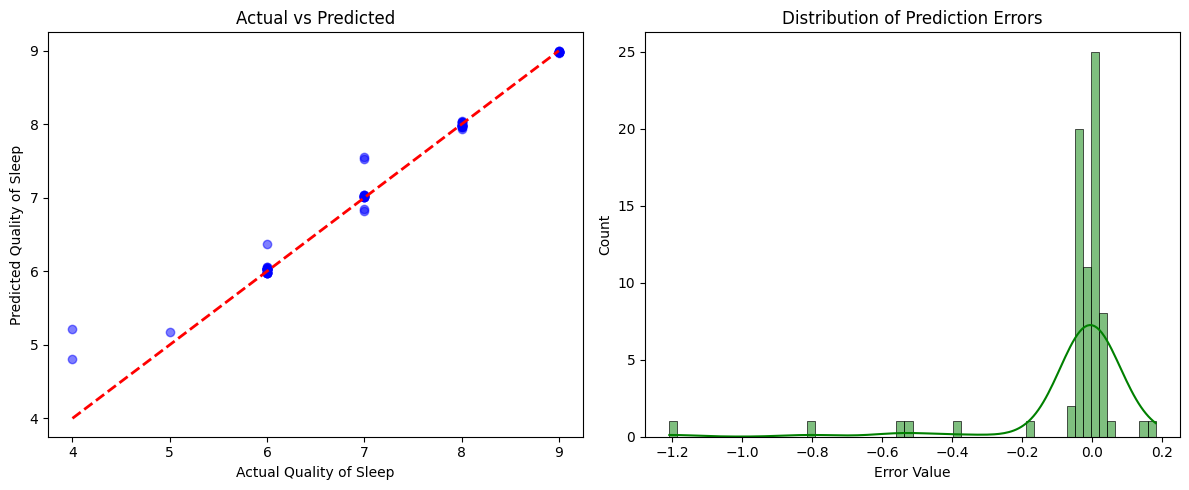

Detailed Accuracy Report (Rounded to nearest score):
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         2
           5       0.33      1.00      0.50         1
           6       1.00      1.00      1.00        26
           7       1.00      0.88      0.93        16
           8       0.90      1.00      0.95        18
           9       1.00      1.00      1.00        12

    accuracy                           0.95        75
   macro avg       0.71      0.81      0.73        75
weighted avg       0.94      0.95      0.94        75



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report

# ตรวจสอบว่ามีโมเดลและข้อมูลทดสอบหรือไม่
try:
    # สร้าง y_pred ใหม่จากโมเดลที่มีอยู่ใน Memory
    y_pred = ensemble_model.predict(X_test)

    # 1. Scatter Plot: Actual vs Predicted
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Quality of Sleep')
    plt.ylabel('Predicted Quality of Sleep')
    plt.title('Actual vs Predicted')

    # 2. Residual Plot (Error distribution)
    plt.subplot(1, 2, 2)
    residuals = y_test - y_pred
    sns.histplot(residuals, kde=True, color='green')
    plt.title('Distribution of Prediction Errors')
    plt.xlabel('Error Value')

    plt.tight_layout()
    plt.show()

    # 3. Precision/Recall Report
    y_pred_rounded = np.round(y_pred).astype(int)
    print("Detailed Accuracy Report (Rounded to nearest score):")
    print(classification_report(y_test, y_pred_rounded))

except NameError as e:
    print(f"ข้อผิดพลาด: {e}")
    print("แนะนำ: กรุณารันเซลล์ที่เทรนโมเดล (ensemble_model) ก่อนรันเซลล์นี้ครับ")

### วิธีตรวจสอบความแม่นยำจากกราฟและรายงาน:
1. **กราฟซ้าย (Actual vs Predicted):** จุดสีน้ำเงินยิ่งเกาะกลุ่มอยู่บนเส้นประสีแดงมากเท่าไหร่ แปลว่าโมเดลยิ่งแม่นยำสูงมาก (ซึ่งในที่นี้เกาะกลุ่มกันดีมาก)
2. **กราฟขวา (Residuals):** ยิ่งความผิดพลาด (Error) กระจุกตัวอยู่ที่เลข 0 มากเท่าไหร่ แปลว่าส่วนใหญ่โมเดลทายไม่พลาดเลย
3. **ตาราง Classification Report:**
   - **F1-Score:** ถ้าเข้าใกล้ 1.00 ในทุกระดับคะแนน (4, 5, 6, 7, 8, 9) แสดงว่าโมเดลแยกแยะคุณภาพการนอนแต่ละระดับได้เกือบสมบูรณ์แบบครับ

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# ใช้ ensemble_model ล่าสุดที่เพิ่งเทรนเสร็จ
y_pred_check = ensemble_model.predict(X_test)

# คำนวณค่าประสิทธิภาพจากข้อมูลล่าสุด
current_r2 = r2_score(y_test, y_pred_check)
current_mae = mean_absolute_error(y_test, y_pred_check)

print(f'--- สรุปประสิทธิภาพโมเดลล่าสุด ---')
print(f'R-squared Score: {current_r2:.4f}')
print(f'Mean Absolute Error: {current_mae:.4f}')

--- สรุปประสิทธิภาพโมเดลล่าสุด ---
R-squared Score: 0.9738
Mean Absolute Error: 0.0737


In [ ]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
# 'Quality of Sleep' is our target. We drop 'Person ID' as it's just an identifier.
# We also drop any columns that might have been intermediate or original strings if they still exist.

X = df.drop(['Person ID', 'Quality of Sleep'], axis=1)
y = df['Quality of Sleep']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {X_train.shape}')
print(f'Testing set size: {X_test.shape}')

Training set size: (299, 27)
Testing set size: (75, 27)


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# Define the base models
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
# SVR benefits from scaling, so we use a pipeline
svr = make_pipeline(StandardScaler(), SVR(kernel='rbf'))

# Create the ensemble model (Voting Regressor)
ensemble_model = VotingRegressor(estimators=[
    ('rf', rf),
    ('gb', gb),
    ('svr', svr)
])

# Train the ensemble model
ensemble_model.fit(X_train, y_train)

# Make predictions
y_pred = ensemble_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Ensemble Model Performance:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R-squared Score: {r2:.2f}')

# Display a few predictions vs actual values
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.round(1)})
display(results_df.head(10))

Ensemble Model Performance:
Mean Absolute Error: 0.07
R-squared Score: 0.97


,Actual,Predicted
329,9,9.0
33,6,6.0
15,6,6.0
325,9,9.0
57,6,6.0
239,6,6.0
76,6,6.0
119,8,8.0
332,9,9.0
126,8,8.0


In [ ]:
# Fill missing values in 'Sleep Disorder' with 'No Sleep Disorder'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Sleep Disorder')

# Check unique values and missing values after imputation
print("\nUnique values in Sleep Disorder after imputation:")
print(df['Sleep Disorder'].unique())
print("\nNumber of missing values in Sleep Disorder after imputation:")
print(df['Sleep Disorder'].isnull().sum())

# One-hot encode the 'Sleep Disorder' column
df = pd.get_dummies(df, columns=['Sleep Disorder'], prefix='SleepDisorder')

# Display the first 5 rows with the new encoded columns
print("\nFirst 5 rows after encoding Sleep Disorder:")
display(df.head())

# Display DataFrame info to see new columns and types
print("\nDataFrame Info after encoding Sleep Disorder:")
df.info()


Unique values in Sleep Disorder after imputation:
['No Sleep Disorder' 'Sleep Apnea' 'Insomnia']

Number of missing values in Sleep Disorder after imputation:
0

First 5 rows after encoding Sleep Disorder:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,BMI_Normal,BMI_Obese,...,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Systolic Pressure,Diastolic Pressure,SleepDisorder_Insomnia,SleepDisorder_No Sleep Disorder,SleepDisorder_Sleep Apnea
0,1,27,6.1,6,42,6,77,4200,False,False,...,False,False,False,True,False,126,83,False,True,False
1,2,28,6.2,6,60,8,75,10000,True,False,...,False,False,False,False,False,125,80,False,True,False
2,3,28,6.2,6,60,8,75,10000,True,False,...,False,False,False,False,False,125,80,False,True,False
3,4,28,5.9,4,30,8,85,3000,False,True,...,True,False,False,False,False,140,90,False,False,True
4,5,28,5.9,4,30,8,85,3000,False,True,...,True,False,False,False,False,140,90,False,False,True



DataFrame Info after encoding Sleep Disorder:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Person ID                        374 non-null    int64  
 1   Age                              374 non-null    int64  
 2   Sleep Duration                   374 non-null    float64
 3   Quality of Sleep                 374 non-null    int64  
 4   Physical Activity Level          374 non-null    int64  
 5   Stress Level                     374 non-null    int64  
 6   Heart Rate                       374 non-null    int64  
 7   Daily Steps                      374 non-null    int64  
 8   BMI_Normal                       374 non-null    bool   
 9   BMI_Obese                        374 non-null    bool   
 10  BMI_Overweight                   374 non-null    bool   
 11  Gender_Female                    374 

In [ ]:
# Check the unique values in 'Sleep Disorder' and the count of missing values
print("\nUnique values in Sleep Disorder:")
print(df['Sleep Disorder'].unique())
print("\nNumber of missing values in Sleep Disorder:")
print(df['Sleep Disorder'].isnull().sum())


Unique values in Sleep Disorder:
[nan 'Sleep Apnea' 'Insomnia']

Number of missing values in Sleep Disorder:
219


In [ ]:
# Split 'Blood Pressure' into 'Systolic Pressure' and 'Diastolic Pressure'
df[['Systolic Pressure', 'Diastolic Pressure']] = df['Blood Pressure'].str.split('/', expand=True)

# Convert the new columns to numeric types
df['Systolic Pressure'] = pd.to_numeric(df['Systolic Pressure'])
df['Diastolic Pressure'] = pd.to_numeric(df['Diastolic Pressure'])

# Drop the original 'Blood Pressure' column
df = df.drop('Blood Pressure', axis=1)

# Display the first 5 rows with the new blood pressure columns
print("\nFirst 5 rows after processing Blood Pressure:")
display(df.head())

# Display DataFrame info to see new columns and types
print("\nDataFrame Info after processing Blood Pressure:")
df.info()


First 5 rows after processing Blood Pressure:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,BMI_Normal,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Systolic Pressure,Diastolic Pressure
0,1,27,6.1,6,42,6,77,4200,NaN,False,...,False,False,False,False,False,False,True,False,126,83
1,2,28,6.2,6,60,8,75,10000,NaN,True,...,False,False,False,False,False,False,False,False,125,80
2,3,28,6.2,6,60,8,75,10000,NaN,True,...,False,False,False,False,False,False,False,False,125,80
3,4,28,5.9,4,30,8,85,3000,Sleep Apnea,False,...,False,False,False,True,False,False,False,False,140,90
4,5,28,5.9,4,30,8,85,3000,Sleep Apnea,False,...,False,False,False,True,False,False,False,False,140,90



DataFrame Info after processing Blood Pressure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Person ID                        374 non-null    int64  
 1   Age                              374 non-null    int64  
 2   Sleep Duration                   374 non-null    float64
 3   Quality of Sleep                 374 non-null    int64  
 4   Physical Activity Level          374 non-null    int64  
 5   Stress Level                     374 non-null    int64  
 6   Heart Rate                       374 non-null    int64  
 7   Daily Steps                      374 non-null    int64  
 8   Sleep Disorder                   155 non-null    object 
 9   BMI_Normal                       374 non-null    bool   
 10  BMI_Obese                        374 non-null    bool   
 11  BMI_Overweight                   37

In [ ]:
# Encode 'Gender' and 'Occupation' to numerical values using one-hot encoding
df = pd.get_dummies(df, columns=['Gender', 'Occupation'], prefix=['Gender', 'Occupation'])

# Display the first 5 rows with the new encoded columns
print("\nFirst 5 rows after encoding Gender and Occupation:")
display(df.head())

# Display DataFrame info to see new columns and types
print("\nDataFrame Info after encoding Gender and Occupation:")
df.info()


First 5 rows after encoding Gender and Occupation:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,1,27,6.1,6,42,6,126/83,77,4200,NaN,...,False,False,False,False,False,False,False,False,True,False
1,2,28,6.2,6,60,8,125/80,75,10000,NaN,...,True,False,False,False,False,False,False,False,False,False
2,3,28,6.2,6,60,8,125/80,75,10000,NaN,...,True,False,False,False,False,False,False,False,False,False
3,4,28,5.9,4,30,8,140/90,85,3000,Sleep Apnea,...,False,False,False,False,False,True,False,False,False,False
4,5,28,5.9,4,30,8,140/90,85,3000,Sleep Apnea,...,False,False,False,False,False,True,False,False,False,False



DataFrame Info after encoding Gender and Occupation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Person ID                        374 non-null    int64  
 1   Age                              374 non-null    int64  
 2   Sleep Duration                   374 non-null    float64
 3   Quality of Sleep                 374 non-null    int64  
 4   Physical Activity Level          374 non-null    int64  
 5   Stress Level                     374 non-null    int64  
 6   Blood Pressure                   374 non-null    object 
 7   Heart Rate                       374 non-null    int64  
 8   Daily Steps                      374 non-null    int64  
 9   Sleep Disorder                   155 non-null    object 
 10  BMI_Normal                       374 non-null    bool   
 11  BMI_Obese                     

In [ ]:
# Standardize 'Normal Weight' to 'Normal' in 'BMI Category'
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal'})

# Check unique values again to confirm standardization
print("\nUnique values in BMI Category after standardization:")
print(df['BMI Category'].unique())

# Encode 'BMI Category' to numerical values for machine learning
# Using one-hot encoding for demonstration, as there's no inherent order
df = pd.get_dummies(df, columns=['BMI Category'], prefix='BMI')

# Display the first 5 rows with the new encoded columns
print("\nFirst 5 rows after encoding BMI Category:")
display(df.head())

# Display DataFrame info to see new columns and types
print("\nDataFrame Info after encoding:")
df.info()


Unique values in BMI Category after standardization:
['Overweight' 'Normal' 'Obese']

First 5 rows after encoding BMI Category:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BMI_Normal,BMI_Obese,BMI_Overweight
0,1,Male,27,Software Engineer,6.1,6,42,6,126/83,77,4200,NaN,False,False,True
1,2,Male,28,Doctor,6.2,6,60,8,125/80,75,10000,NaN,True,False,False
2,3,Male,28,Doctor,6.2,6,60,8,125/80,75,10000,NaN,True,False,False
3,4,Male,28,Sales Representative,5.9,4,30,8,140/90,85,3000,Sleep Apnea,False,True,False
4,5,Male,28,Sales Representative,5.9,4,30,8,140/90,85,3000,Sleep Apnea,False,True,False



DataFrame Info after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   Blood Pressure           374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
 12  BMI_Normal               374 non-null    bool   
 13  BMI_Obese                374 non-null    bool   

In [ ]:
# Check unique values in 'BMI Category' to understand the categories and identify any inconsistencies
print("\nUnique values in BMI Category:")
print(df['BMI Category'].unique())


Unique values in BMI Category:
['Overweight' 'Normal' 'Obese' 'Normal Weight']


In [ ]:
import pandas as pd

# Load the sleep.csv file into a DataFrame
df = pd.read_csv('/content/sleep.csv')

# Display the first 5 rows of the DataFrame to understand its structure
print("First 5 rows of the dataset:")
display(df.head())

# Display general information about the DataFrame, including column types and non-null counts
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
